# EDA - league_model

Exploration of `riot_dataset/features.csv` (one row per minute of each match).

Context: the tabular model plateaus at roughly AUC 0.86, and four separate levers
(more data, hyperparameter tuning, an LSTM, and extra timeline features) failed to
move it, which suggests the ceiling is intrinsic to the game rather than a modeling
gap. As a reference point, `gold_diff` on its own already reaches AUC 0.84.

This notebook answers five questions:

1. What does the data look like?
2. Does the value of each feature depend on the minute of the game?
3. How much collinearity is there, and what can be pruned?
4. Is the model calibrated (does a predicted 70% win about 70% of the time)?
5. Is the model stable across patches?

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score

pd.set_option('display.width', 140)
plt.rcParams['figure.figsize'] = (11, 4)

df = pd.read_csv('../riot_dataset/features.csv')
df_ranks = pd.read_csv('../riot_dataset/match_rank.csv')

df = df.merge(df_ranks, on='match_id', how='left')
print(df.shape)
df.head()

(230210, 40)


,match_id,queue_id,tier_x,division_x,patch,minute,blue_win,gold_diff,xp_diff,cs_diff,...,xp_diff_BOT,gold_diff_SUP,xp_diff_SUP,gold_diff_d5,xp_diff_d5,kills_diff_d5,cs_diff_d5,level_diff_d5,tier_y,division_y
0,EUW1_7880487704,420,UNKNOWN,NaN,16.11,5,1,-393,392,3,...,-258,28,65,0,0,0,0,0,NaN,NaN
1,EUW1_7880487704,420,UNKNOWN,NaN,16.11,6,1,199,791,9,...,-29,143,39,0,0,0,0,0,NaN,NaN
2,EUW1_7880487704,420,UNKNOWN,NaN,16.11,7,1,-31,756,6,...,20,112,-283,0,0,0,0,0,NaN,NaN
3,EUW1_7880487704,420,UNKNOWN,NaN,16.11,8,1,-422,736,7,...,-20,74,-323,0,0,0,0,0,NaN,NaN
4,EUW1_7880487704,420,UNKNOWN,NaN,16.11,9,1,-862,110,7,...,207,10,-500,0,0,0,0,0,NaN,NaN


## 1. Overview

In [4]:
print('Rows           :', len(df))
print('Matches        :', df.match_id.nunique())
print('Balance blue_win:', round(df.blue_win.mean(), 4))
print('Minutes        :', df.minute.min(), '->', df.minute.max())
print('\nMatches per patch:')
print(df.groupby('patch').match_id.nunique().sort_index())
print('\nMatch duration (minutes per game):')
print(df.groupby('match_id').minute.max().describe())

Rows           : 230210
Matches        : 9839
Balance blue_win: 0.5179
Minutes        : 5 -> 58

Matches per patch:
patch
16.11       6
16.12     175
16.13    7963
16.14    1695
Name: match_id, dtype: int64

Match duration (minutes per game):
count    9839.000000
mean       27.397703
std         6.034922
min         5.000000
25%        24.000000
50%        27.000000
75%        31.000000
max        58.000000
Name: minute, dtype: float64


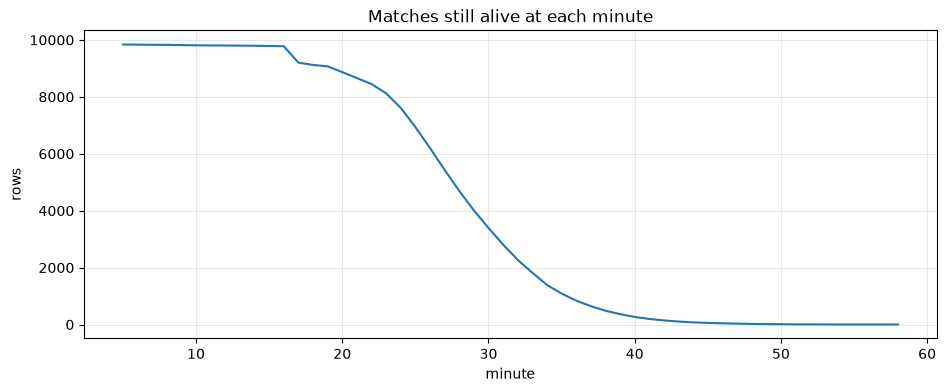

In [5]:
# how many rows survive at each minute (long matches are a minority)
counts = df.groupby('minute').size()
counts.plot(title='Matches still alive at each minute', xlabel='minute', ylabel='rows')
plt.grid(alpha=.3); plt.show()

**Takeaway.** The dataset holds 9,839 matches expanded into about 230,000
minute-level rows. Blue side wins 51.8% of games, the small structural side
advantage is well documented for the blue side. Games span minute 5 (where
sampling begins) to minute 58, with a median length of 27 minutes, so most of the
data lives between minutes 15 and 35 and the row count falls off sharply after that.
Almost every match comes from patch 16.13, so patch drift is not a concern for this
snapshot.

## 2. Distributions

`gold_diff` split by outcome at several minutes. We expect the win and loss
distributions to pull apart as the game progresses.

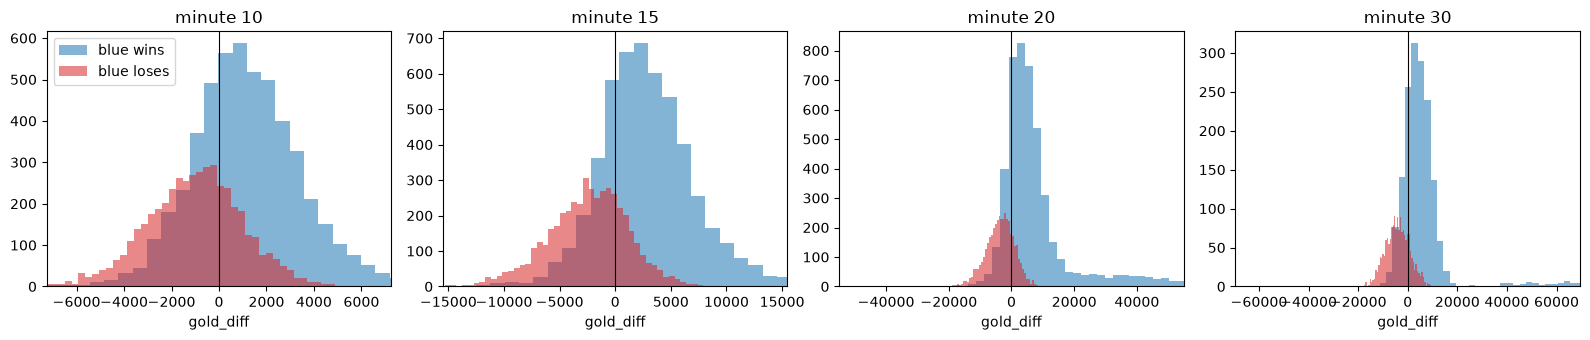

In [5]:
import matplotlib.ticker as mticker

fig, axes = plt.subplots(1, 4, figsize=(16, 3.5))
for ax, m in zip(axes, [10, 15, 20, 30]):
    d = df[df.minute == m]
    for win, label, color in [(1, 'blue wins', 'tab:blue'), (0, 'blue loses', 'tab:red')]:
        ax.hist(d[d.blue_win == win].gold_diff, bins=50, alpha=.55, label=label, color=color)
    ax.set_title(f'minute {m}'); ax.set_xlabel('gold_diff'); ax.axvline(0, color='k', lw=.8)

    # remove outliers for better visualization
    lo, hi = d.gold_diff.quantile([0.01, 0.99])
    lim = max(abs(lo), abs(hi))
    ax.set_xlim(-lim, lim)
axes[0].legend()
plt.tight_layout(); plt.show()

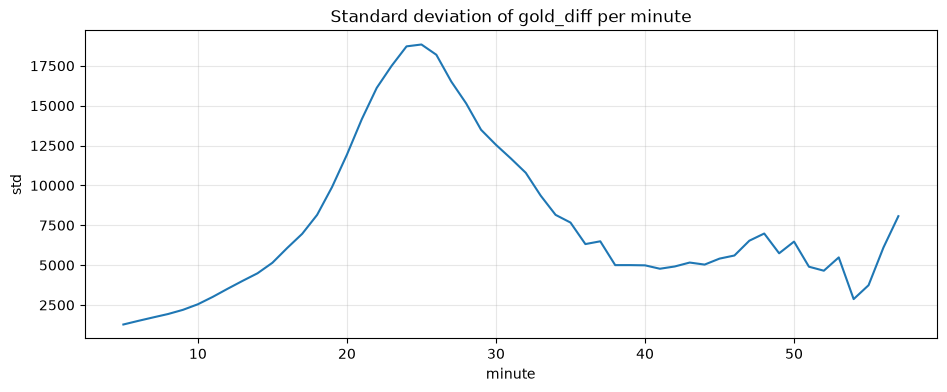

In [6]:
# how much does the gold advantage spread over time?
df.groupby('minute').gold_diff.std().plot(
    title='Standard deviation of gold_diff per minute', xlabel='minute', ylabel='std')
plt.grid(alpha=.3); plt.show()

**Takeaway.** At minute 10 the win and loss distributions of `gold_diff` overlap
the most, so an early gold lead says little. By minutes 20 to 30 the two bells are
most separated with the tail of each more to the center (0). The
standard deviation of `gold_diff` also grows steadily with the minute, meaning
advantages compound over time, until minute 25-30 where it starts to go down. Which makes sense since
the more length the less gold matters. This is why the raw gold number is not comparable
across minutes and why `minute` is kept as a feature.

## 3. Predictive power per minute

The key question: is a baron at minute 20 worth the same as a baron at minute 40?

For each feature and each minute we compute the AUC of that variable alone against
`blue_win`. 

Note: `max(auc, 1 - auc)` is used to ignore the sign, and any minute where the
variable is constant is skipped (for example `baron_diff` is 0 in every match before
minute 20, so AUC cannot be measured there).

In [7]:
def auc_per_minute(df, col, minutes=range(5, 41), min_rows=200):
    """AUC of a single feature against blue_win, minute by minute."""
    out = {}
    for m in minutes:
        d = df[df.minute == m]
        if len(d) < min_rows or d.blue_win.nunique() < 2 or d[col].std() == 0:
            continue
        a = roc_auc_score(d.blue_win, d[col])
        out[m] = max(a, 1 - a)
    return pd.Series(out)

FEATS = ['gold_diff', 'kills_diff', 'tower_diff', 'inhib_diff',
         'dragon_diff', 'herald_diff', 'baron_diff', 'grub_diff',
         'gold_diff_d5', 'cs_diff', 'xp_diff']
curves = {c: auc_per_minute(df, c) for c in FEATS}
table = pd.DataFrame(curves)
table.round(3)

,gold_diff,kills_diff,tower_diff,inhib_diff,dragon_diff,herald_diff,baron_diff,grub_diff,gold_diff_d5,cs_diff,xp_diff
5,0.688,0.679,0.500,NaN,NaN,NaN,NaN,NaN,NaN,0.609,0.651
6,0.705,0.698,0.501,0.500,0.523,NaN,NaN,NaN,NaN,0.623,0.669
7,0.728,0.722,0.501,0.500,0.578,NaN,NaN,NaN,NaN,0.635,0.687
8,0.740,0.735,0.503,0.500,0.598,NaN,NaN,NaN,NaN,0.647,0.707
9,0.755,0.751,0.505,0.501,0.614,NaN,NaN,0.543,NaN,0.659,0.722
10,0.770,0.764,0.514,0.501,0.629,NaN,NaN,0.551,0.737,0.674,0.738
11,0.784,0.779,0.537,0.501,0.637,NaN,NaN,0.558,0.743,0.692,0.754
12,0.801,0.794,0.589,0.501,0.662,NaN,NaN,0.560,0.761,0.708,0.767
13,0.817,0.811,0.649,0.501,0.684,NaN,NaN,0.560,0.782,0.723,0.790
14,0.831,0.827,0.694,0.502,0.694,NaN,0.500,0.560,0.797,0.739,0.813


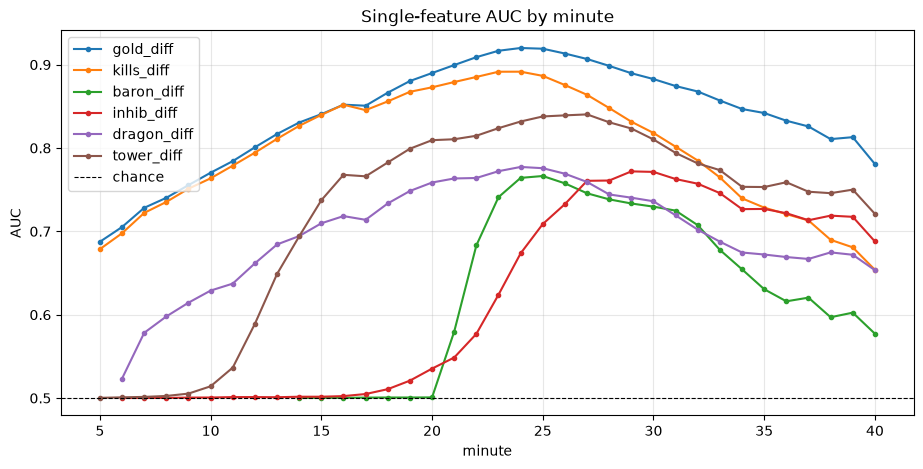

In [8]:
fig, ax = plt.subplots(figsize=(11, 5))
for c in ['gold_diff', 'kills_diff', 'baron_diff', 'inhib_diff', 'dragon_diff', 'tower_diff']:
    table[c].dropna().plot(ax=ax, marker='.', label=c)
ax.axhline(.5, color='k', ls='--', lw=.8, label='chance')
ax.set_title('Single-feature AUC by minute')
ax.set_xlabel('minute'); ax.set_ylabel('AUC'); ax.legend(); ax.grid(alpha=.3)
plt.show()

**Takeaway.** As we can see some features hace a big correlation, gold and kills until minute 25 almost overlap. Since every kill gives gold, and more gold leads to more kills. 

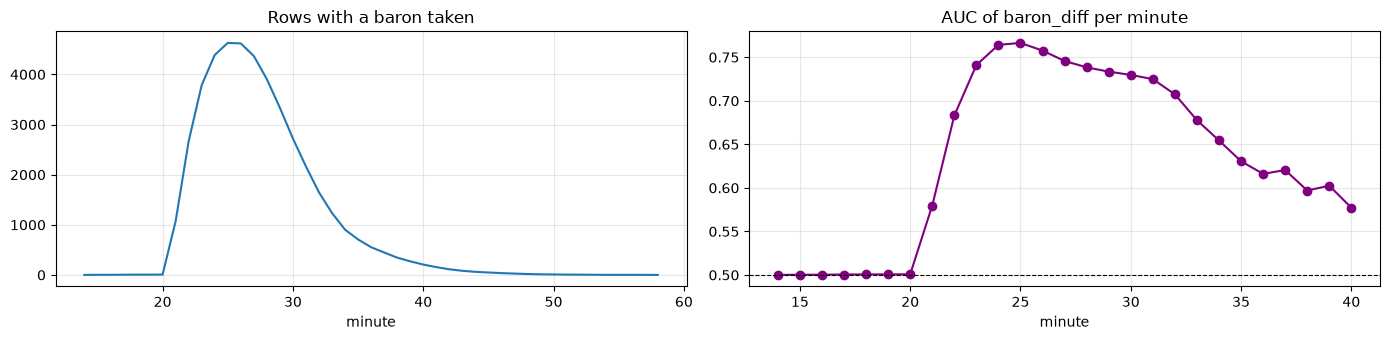

min 25: with a baron advantage -> winrate 0.775  (n=2168)
min 30: with a baron advantage -> winrate 0.705  (n=1314)
min 35: with a baron advantage -> winrate 0.634  (n=347)
min 40: with a baron advantage -> winrate 0.643  (n=84)


In [9]:
# the baron in detail: when does it appear and how much does it inform?
b = df[df.baron_diff != 0].groupby('minute').size()
fig, (a1, a2) = plt.subplots(1, 2, figsize=(14, 3.5))
b.plot(ax=a1, title='Rows with a baron taken', xlabel='minute'); a1.grid(alpha=.3)
table['baron_diff'].dropna().plot(ax=a2, marker='o', color='purple',
                                   title='AUC of baron_diff per minute', xlabel='minute')
a2.axhline(.5, color='k', ls='--', lw=.8); a2.grid(alpha=.3)
plt.tight_layout(); plt.show()

# conditional winrate: given a baron advantage at minute X, how often do you win?
for m in [20, 25, 30, 35, 40]:
    d = df[(df.minute == m) & (df.baron_diff > 0)]
    if len(d) > 30:
        print(f'min {m:>2}: with a baron advantage -> winrate {d.blue_win.mean():.3f}  (n={len(d)})')

**Takeaway.** Every feature has a window where it matters most, with a peak for all around minute 25.
`baron_diff` jumps to AUC 0.77 right after the baron spawns and then decays toward 0.58 by minute
40, showing that baron losses more games than it wins. The conditional winrate tells the same story: holding a baron is worth about
77% at minute 25 but only around 64% by minute 40, because a late baron usually
happens in an already-even game. This is direct evidence that a baron at minute 25
is not the same as a baron at minute 40, and it is the strongest case for a
`baron x minute` value.

## 4. Collinearity

We suspect that `gold`, `xp`, `cs` and `level` move together. Here it is quantified:
anything highly correlated is a candidate to prune.

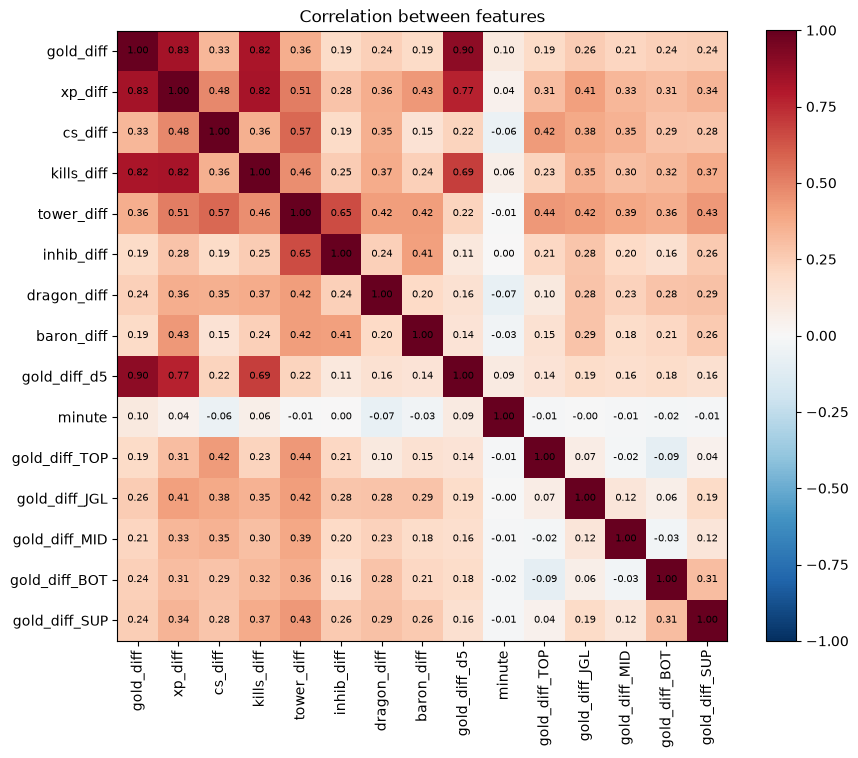

In [10]:
cols = ['gold_diff', 'xp_diff', 'cs_diff', 'kills_diff', 'tower_diff', 'inhib_diff',
        'dragon_diff', 'baron_diff', 'gold_diff_d5', 'minute',
        'gold_diff_TOP', 'gold_diff_JGL', 'gold_diff_MID', 'gold_diff_BOT', 'gold_diff_SUP']
corr = df[cols].corr()

fig, ax = plt.subplots(figsize=(9, 7.5))
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(cols))); ax.set_xticklabels(cols, rotation=90)
ax.set_yticks(range(len(cols))); ax.set_yticklabels(cols)
for i in range(len(cols)):
    for j in range(len(cols)):
        ax.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center', fontsize=7)
plt.colorbar(im); plt.title('Correlation between features'); plt.tight_layout(); plt.show()

**Takeaway.** The economy features are highly redundant. `gold_diff` correlates
0.88 with `level_diff`, 0.83 with `xp_diff` and 0.82 with `kills_diff`, but only
0.33 with `cs_diff`. Because gold, xp and level carry almost the same information,
the served model drops gold and xp (which are not available live for all ten
players anyway) and keeps the cheaper live-available proxies, kills, cs and level,
with almost no loss in AUC.

In [11]:
# global predictive power of each single feature (quick screening)
rows = []
for c in df.columns:
    if c in ('match_id', 'patch', 'blue_win') or not pd.api.types.is_numeric_dtype(df[c]) or df[c].isna().any() or df[c].std() == 0:
        continue
    a = roc_auc_score(df.blue_win, df[c])
    rows.append({'feature': c, 'auc_alone': round(max(a, 1 - a), 4)})
pd.DataFrame(rows).sort_values('auc_alone', ascending=False).reset_index(drop=True)

,feature,auc_alone
0,gold_diff,0.8387
1,xp_diff,0.8207
2,kills_diff,0.8169
3,level_diff,0.8121
4,kills_diff_d5,0.7800
5,gold_diff_d5,0.7690
6,dmg_champs_diff,0.7631
7,xp_diff_d5,0.7548
8,tower_diff,0.7176
9,xp_diff_JGL,0.7173


**Takeaway.** No single feature comes close to the full model. On its own,
`gold_diff` reaches AUC 0.84, followed by `xp_diff` (0.82), `kills_diff` (0.82) and
`level_diff` (0.81). The momentum deltas (`_d5`) land around 0.75 to 0.78. Since the
best single feature is well below the combined model, the model's performance comes
from aggregating state and momentum, even if it is a simple improvement.

However gold, xp and kills have a big correlation. Since they usually move together, but they cannot be removed. If a player has a lot of kills, but another player has a lot of cs (more gold from cs than kills in correlation), the compound effect of kills and cs is more important than just one of them. So the model needs to keep all three features.

## 5. Calibration

AUC measures ranking. Calibration measures whether the number means something: out
of all the times the model says 70%, does 70% actually win? For a win-probability
product this matters more than AUC.

In [12]:
import joblib
from sklearn.model_selection import GroupShuffleSplit
from sklearn.calibration import calibration_curve

bundle = joblib.load('../models/baseline_model.joblib')
model, FEATURES = bundle['model'], bundle['features']

# same per-match split as in training
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
_, test_idx = next(gss.split(df[FEATURES].values, df.blue_win.values, df.match_id.values))
te = df.iloc[test_idx]
proba = model.predict_proba(te[FEATURES].values)[:, 1]
print('Test:', len(te), 'rows /', te.match_id.nunique(), 'matches')

Test: 46213 rows / 1968 matches


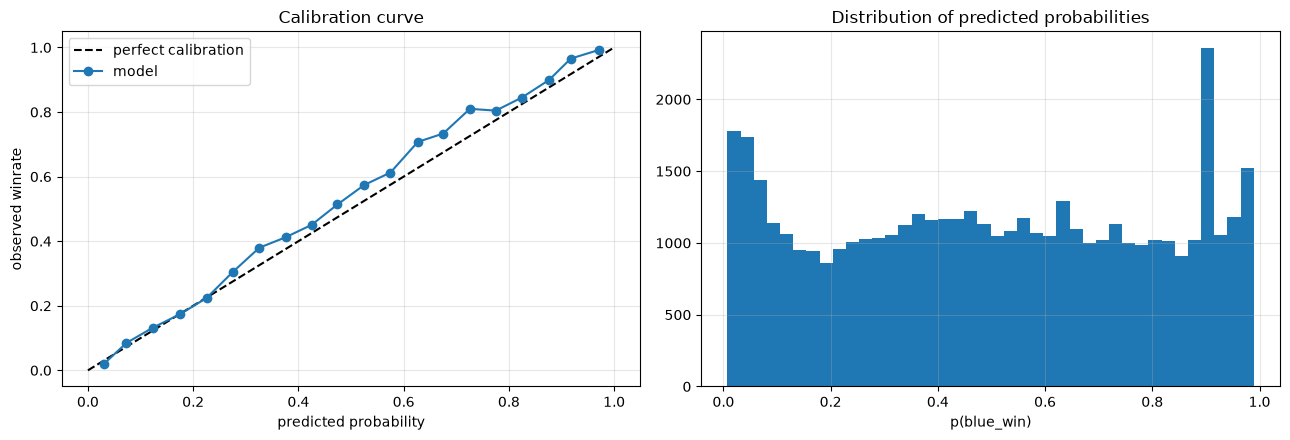

In [13]:
frac_pos, mean_pred = calibration_curve(te.blue_win, proba, n_bins=20)

fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4.5))
a1.plot([0, 1], [0, 1], 'k--', label='perfect calibration')
a1.plot(mean_pred, frac_pos, 'o-', label='model')
a1.set_xlabel('predicted probability'); a1.set_ylabel('observed winrate')
a1.set_title('Calibration curve'); a1.legend(); a1.grid(alpha=.3)
a2.hist(proba, bins=40); a2.set_title('Distribution of predicted probabilities')
a2.set_xlabel('p(blue_win)'); a2.grid(alpha=.3)
plt.tight_layout(); plt.show()

**Takeaway.** The reliability curve follows the diagonal closely across the whole
range: when the model predicts 20% it wins about 20% of the time, and the same holds
at the high end. Deviations from the diagonal are small, which is expected given the
randomness of the problem. The probability histogram is spread across the full range rather than
piled up near 50%, so the model is confident when the game state justifies it.

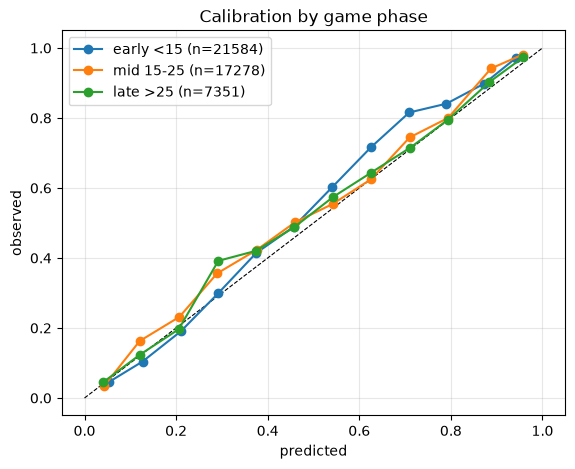

In [14]:
# calibration per phase: does it drift in early vs late game?
t = te.copy(); t['proba'] = proba
t['phase'] = pd.cut(t.minute, [0, 15, 25, 200], labels=['early <15', 'mid 15-25', 'late >25'])
fig, ax = plt.subplots(figsize=(6.5, 5))
ax.plot([0, 1], [0, 1], 'k--', lw=.8)
for phase, g in t.groupby('phase', observed=True):
    fp, mp = calibration_curve(g.blue_win, g.proba, n_bins=12)
    ax.plot(mp, fp, 'o-', label=f'{phase} (n={len(g)})')
ax.set_xlabel('predicted'); ax.set_ylabel('observed'); ax.legend()
ax.set_title('Calibration by game phase'); ax.grid(alpha=.3)
plt.show()

**Takeaway.** Breaking the test set into early (before minute 15), mid (15 to 25)
and late (after minute 25) phases, each curve stays near the diagonal. The model is
not systematically over or under-confident in any single phase, so the aggregate
calibration is not hiding a bad early game averaged against a good late game.

## 6. Stability across patches

An empirical test that the model is version-agnostic: if the `gold_diff -> winrate`
relationship overlaps across patches, that supports using no patch feature.

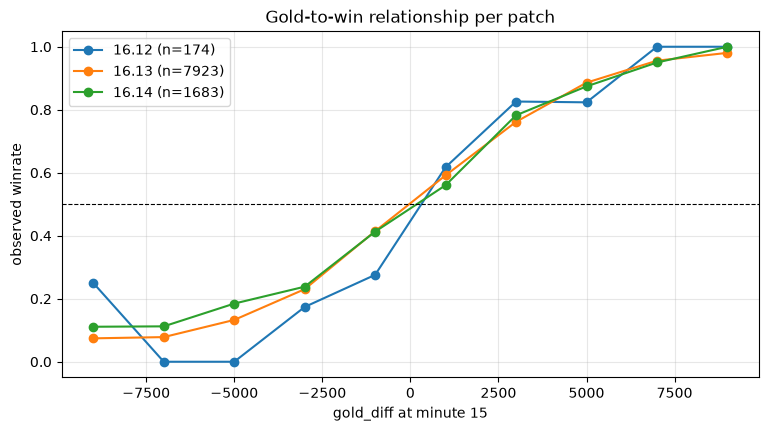

In [15]:
d = df[df.minute == 15].copy()
d['bucket'] = pd.cut(d.gold_diff, np.arange(-10000, 10001, 2000))

fig, ax = plt.subplots(figsize=(9, 4.5))
for patch, g in d.groupby('patch'):
    if g.match_id.nunique() < 100:
        continue
    wr = g.groupby('bucket', observed=True).blue_win.mean()
    ax.plot([b.mid for b in wr.index], wr.values, 'o-', label=f'{patch} (n={g.match_id.nunique()})')
ax.axhline(.5, color='k', ls='--', lw=.8)
ax.set_xlabel('gold_diff at minute 15'); ax.set_ylabel('observed winrate')
ax.set_title('Gold-to-win relationship per patch')
ax.legend(); ax.grid(alpha=.3)
plt.show()

**Takeaway.** The gold-to-winrate curves at minute 15 overlap across the patches
with enough matches to measure. A given gold lead converts to about the same win
rate regardless of patch, so the model does not need a patch feature and should
generalize to future patches that keep the same core rules. This matches the design
decision to leave patch out of the feature set.

The only time we _could_ change the patch, it's when a new seasson, champ or anything that changes the core rules of the game is added. However, since all of our features come from fundamental game mechanics, the model should generalize to almost any future patches.